In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

1038
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_scan_ = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_ = "../QuCF/simulations/Stepanoff/BE-diag-neg"
for i in range(100):
    plt.close()

In [5]:
# -------------------------------------------------------------------------------
# --- Create a diagonal matrix with x-coordinates on the main diagonal ---
# -------------------------------------------------------------------------------
def create_diag_matrix(t, n_half, alpha, name_matrix):
    n = n_half + 1
    N_half = 1 << n_half
    N = 1 << n
    c_arr = np.arange(-N_half, N_half)

    aa = np.linspace(0, 2.*np.pi, N)
    diag = np.zeros(N**2)
    count = -1
    beta_qsp = None


    if name_matrix == "M0":
        for i2 in range(N):
            for i1 in range(N):
                count += 1
                diag[count] = - 2. * (1. - alpha) * c_arr[i1]
                beta_qsp = - 2. * (1. - alpha) * t


    if name_matrix == "M1":
        for i2 in range(N):
            for i1 in range(N):
                count += 1
                diag[count] = - (1. - alpha) * c_arr[i1] * (1. - np.cos(aa[i2]))
                beta_qsp = - (1. - alpha) * t * 2.    # here, 2. is because of the LCU
                                                      # block-encode (1 - cos)

    if name_matrix == "M2":  # !!! indices are taken in the wrong order to simplify the comparison with QuCF !!!
        for i2 in range(N):
            for i1 in range(N):
                count += 1
                diag[count] = - alpha * c_arr[i1] * (1. - np.cos(aa[i2]))
                beta_qsp = alpha * t * 2.   # here, 2. is because of the LCU
                                            # block-encode - (1 - cos)

    if n <= 8:
        A = np.diag(diag)
    else:
        A = None

    # --- Print some circuit parameters ---
    print("---------------------------------------------")

    # --- QSP parameters ---
    print("\n--- QSP parameters: use them to compute QSP angles")
    beta_arr = np.zeros(n, dtype=float)
    for ii in range(n):
        beta_loc = beta_qsp * 2**ii
        beta_arr[ii] = beta_loc
        # print("qubit = {:d}: beta_qsp = {:0.12e}".format(ii, beta_loc))
        print("{:0.12e}".format(beta_loc), end=", ")
    beta_shift = beta_qsp * N_half
    print()
    print("t_qsp_shift: {:0.12e}".format(beta_shift))
    print()

    # --- number of qubits ---
    print("\n// --- Number of qubits ---")
    print("\tnx   {:d}".format(n))
    print("\tnxD  {:d}".format(2*n))
    print("\tN_half {:d}".format(N_half))

    # --- for angle = [0, 2*np.pi] ---
    alpha_0 = 0.
    alpha_1 = (2. * np.pi) * N/(2.*(N - 1))

    print("// --- For QSP BE sin oracle ---")
    print("\talpha_qsp_0 \t{:0.12e}".format(alpha_0))
    print("\talpha_qsp_1 \t{:0.12e}".format(alpha_1))

    # --- reference unitary matrix ---
    Nsq = N**2
    diag_U_ref = np.zeros(Nsq, dtype = complex)
    for ii in range(Nsq):
        diag_U_ref[ii] = np.exp(-1j * t * diag[ii])
    # diag_U_ref = np.sort(diag_U_ref)

    return A, name_matrix, diag_U_ref, beta_qsp
# ---------------------------------------------------------------------------
n_half_ = 5
t_ = 0.01

n_ = n_half_ + 1
N_half_ = 1 << n_half_
N_ = 1 << n_
alpha_ = np.sqrt(20.)

# M0_, name_M0_, diag_U_M0_, beta_qsp_M0_  = create_diag_matrix(t_, n_half_, alpha_, name_matrix="M0")
M1_, name_M1_, diag_U_M1_, beta_qsp_M1_  = create_diag_matrix(t_, n_half_, alpha_, name_matrix="M1")
# M2_, name_M2_, diag_U_M2_, beta_qsp_M2_  = create_diag_matrix(t_, n_half_, alpha_, name_matrix="M2")

---------------------------------------------

--- QSP parameters: use them to compute QSP angles
6.944271909999e-02, 1.388854382000e-01, 2.777708764000e-01, 5.555417527999e-01, 1.111083505600e+00, 2.222167011200e+00, 
t_qsp_shift: 2.222167011200e+00


// --- Number of qubits ---
	nx   6
	nxD  12
	N_half 32
// --- For QSP BE sin oracle ---
	alpha_qsp_0 	0.000000000000e+00
	alpha_qsp_1 	3.191459203647e+00


In [91]:
# -------------------------------------------------------------
# --- Compare QuCF and theoretical unitaries ---
# -------------------------------------------------------------
import cmath
def compare_diag_U(name_output, diag_U_ref, name_A, flag_print_diags):
    # --- reading QuCF data ---
    dd_loc = qucf_r.read_matrix_sparse(path_qucf_, name_output)
    U_qucf = dd_loc["A"].dense()

    # # --- Correcting the global phase ---
    gl_phase = cmath.phase(U_qucf[0,0])
    # U_qucf_corr = U_qucf * np.exp(-1j * gl_phase)
    # diag_U_qucf = np.sort(mix.get_diag(U_qucf_corr, 0)[0])

    # diag_U_qucf = np.sort(mix.get_diag(U_qucf, 0)[0])
    diag_U_qucf = np.array(mix.get_diag(U_qucf, 0)[0])

    # diag_U_qucf *= 2.  # because of the LCU used for shifting the indices

    # --- printing diagonals ---
    print("\n\n-------------------------------------------------------------")
    if flag_print_diags:
        mix.print_array(diag_U_ref, n_in_row = N_, ff=[21, 3, "e"])
        print()
        mix.print_array(diag_U_qucf, n_in_row = N_, ff=[21, 3, "e"])
        print()

        print("\n--- array elements where large difference is observe --------------------------------------------")
        diag_diff = np.abs(diag_U_ref - diag_U_qucf)
        thresh_err = 0.1
        ids_err = np.array([i for i, num in enumerate(diag_diff) if num > thresh_err], dtype = int)
        print(diag_U_ref[ids_err]) 
        print()
        print(diag_U_qucf[ids_err])
        print()

    # --- comparison ---
    print("Are the ref and QuCF unitaries close for the propagator {:s}? <<< {:s} >>>".format(
            name_A, str(np.allclose(diag_U_qucf, diag_U_ref, atol = 1e-12))
        )
    )
    # print("Are the absolute values of ref and QuCF unitaries close for the propagator {:s}? <<< {:s} >>>".format(
    #         name_A, str(np.allclose(np.abs(diag_U_qucf), np.abs(diag_U_ref), atol = 1e-12))
    #     )
    # )
    return
# -------------------------------------------------------------------------------
flag_print = True

# compare_diag_U("diag_neg_OUTPUT.hdf5", diag_U_M0_, name_M0_, flag_print)
compare_diag_U("diag_neg_OUTPUT.hdf5", diag_U_M1_, name_M1_, flag_print)
# compare_diag_U("diag_neg_OUTPUT.hdf5", diag_U_M2_, name_M2_, flag_print)
del flag_print

Reading the matrix from: diag_neg_OUTPUT.hdf5
from the path: ../QuCF/simulations/Stepanoff/diag-neg
date of the simulation:  04-02-2025 12:09:34
matrix name:  U
N = 256


-------------------------------------------------------------
 1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j  1.000e+00+0.000e+00j 
 9.713e-01+2.378e-01j  9.780e-01+2.086e-01j  9.838e-01+1.791e-01j  9.888e-01+1.495e-01j  9.928e-01+1.198e-01j  9.959e-01+8.993e-02j  9.982e-01+6.000e-02j  9.995e-01+3.001e-02j  1.000e+00+0.000e+00j  9.995e-01-3.001e-02j  9.982e-01-6.000e-02j  9.959e-01-8.993e-02j  9.928e-01-1.198e-01j  9.888e-01-1.495e-01j  9.838e-01-1.791e-01j  9.780e-01-2.086e-01j 
 6.066e-01+7.950e-01j  6.937e-01+7.203e-01j  7.717e-01+6.360e

Reading the matrix from: diag_neg_OUTPUT.hdf5
from the path: ../QuCF/simulations/Stepanoff/diag-neg
date of the simulation:  03-31-2025 11:38:27
matrix name:  U
N = 64


/media/work/docs/codes/QuCF/scripts-py/env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/media/work/docs/codes/QuCF/scripts-py/env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


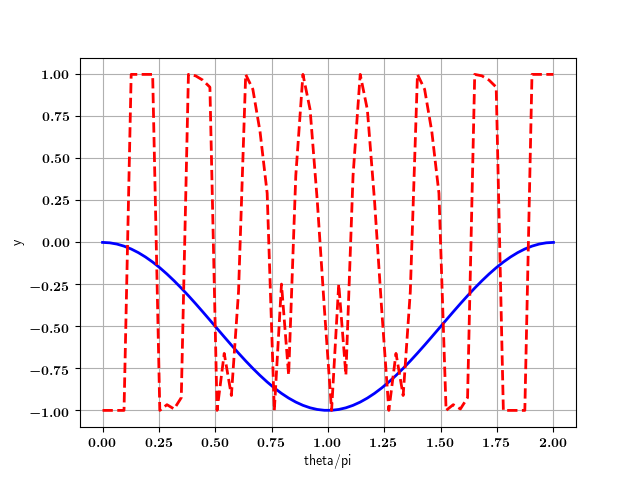

In [ ]:
# -------------------------------------------------------------
# --- Compare QuCF and theoretical unitaries ---
# -------------------------------------------------------------
def plot_diag_U(name_output):
    # --- reading QuCF data ---
    dd_loc = qucf_r.read_matrix_sparse(path_qucf_, name_output)
    U_qucf = dd_loc["A"].dense()

    # --- Correcting the global phase ---
    diag_U_qucf = mix.get_diag(U_qucf, 0)[0]
    N = len(diag_U_qucf)

    # diag_U_qucf = np.sort(mix.get_diag(U_qucf, 0)[0])

    aa = np.linspace(0., 2.*np.pi, N)
    y_ref = -0.5 * (1. - np.cos(aa))

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(aa/np.pi, y_ref,       color="b", linewidth = 2, linestyle='-')
    ax.plot(aa/np.pi, diag_U_qucf, color="r", linewidth = 2, linestyle='--')
    plt.xlabel('theta/pi')
    plt.ylabel("y")
    plt.grid(True)
    plt.show()
    return
# -------------------------------------------------------------------------------
plot_diag_U("diag_neg_OUTPUT.hdf5")

In [80]:
mix.Rz(2.*np.pi)

array([[-1.-1.225e-16j,  0.+0.000e+00j],
       [ 0.+0.000e+00j, -1.+1.225e-16j]])